In [3]:
# Standard library
import pickle

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from joblib import parallel_backend

# Scikit-learn preprocessing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Scikit-learn models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.neighbors import NearestNeighbors

# Scikit-learn model selection and evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

# Scikit-learn utilities
from sklearn.pipeline import Pipeline

In [4]:
def evaluate(true, predicted, display=False):
    # Calculate evaluation metrics
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)

    # Print results
    print("Model Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    if display:
        # Optional: Visualize predictions vs actual values
        plt.figure(figsize=(10, 6))
        plt.scatter(true, predicted, alpha=0.5)
        plt.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title('Actual vs Predicted Values')
        plt.tight_layout()
        plt.show()

In [5]:
def copy_plot(df, savefile=None):
    min_proj = int(df["Projected"].min())
    max_proj = int(df["Projected"].max())
    bins = np.arange(min_proj, max_proj + 2, 1)

    df["Projected_bin"] = pd.cut(df["Projected"], bins=bins, right=False, include_lowest=True)

    bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
    bin_counts = bin_counts_series.values
    bin_labels_intervals = bin_counts_series.index.tolist()

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        x="Projected_bin", y="Actual", data=df,
        palette="Paired",
        showfliers=True
    )

    slope, intercept = np.polyfit(df['Projected'], df['Actual'], 1)
    x_line = np.linspace(df['Projected'].min(), df['Projected'].max(), 100)
    y_line = slope * x_line + intercept

    x_labels_numeric = np.array([interval.left for interval in bin_labels_intervals])
    x_line_indices = np.digitize(x_line, x_labels_numeric) - 1
    x_line_indices = np.clip(x_line_indices, 0, len(x_labels_numeric) - 1)

    # Plot the regression line
    plt.plot(x_line_indices + (x_line - x_labels_numeric[x_line_indices]) / 1.0,
             y_line,
             color="steelblue", alpha=0.7, linewidth=2)

    clean_labels = [f'{interval.left:.1f}' for interval in bin_labels_intervals]
    plt.gca().set_xticklabels(clean_labels)

    y_pos_count = 47
    for i, count in enumerate(bin_counts):
        if count > 0:
            plt.text(i, y_pos_count, str(count),
                     ha="center", va="bottom", fontsize=9, color='black') # Changed color to black

    plt.title("Projected vs Actual by Point Level", fontsize=14)
    plt.xlabel("QB Model Projected Points", fontsize=12)
    plt.ylabel("Actual Points", fontsize=12)

    plt.ylim(-1, 50)

    plt.xticks(rotation=0, ha="center", fontsize=10)

    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, facecolor='w', edgecolor='black')
    plt.show()

In [6]:
def find_noisy_samples(X, y, n_neighbors=5, threshold=2.0):
    """
    Find samples where nearby points have very different target values
    """
    # Find nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    # For each point, check if its target differs from neighbors
    noise_scores = []
    for i in range(len(X)):
        neighbor_indices = indices[i][1:]  # Exclude self
        neighbor_targets = y[neighbor_indices]

        # Calculate how different this point's target is from neighbors
        target_std = np.std(np.append(neighbor_targets, y[i]))
        target_diff = np.abs(y[i] - np.mean(neighbor_targets))

        noise_scores.append(target_diff / (target_std + 1e-10))

    noise_scores = np.array(noise_scores)

    # Flag samples with high noise scores
    noisy_mask = noise_scores > threshold

    return noisy_mask, noise_scores

In [7]:
rb_df = pd.read_csv("../../final_rb_data.csv", index_col=0)
rb_df = rb_df.drop(['PFR_ID', 'Team', 'Opp'], axis=1)

rb_df = pd.get_dummies(rb_df)

train_df = rb_df[rb_df['YEAR'] < 2022]
validation_df = rb_df[rb_df['YEAR'] == 2022]
test_df = rb_df[rb_df['YEAR'] > 2022]

y_train = train_df['PPR'].values
X_train = train_df.drop(['PPR', 'YEAR'], axis=1).values
train_year = train_df['YEAR'].values
X_train_df = train_df.drop(['PPR', 'YEAR'], axis=1)

y_valid = validation_df['PPR'].values
X_valid = validation_df.drop(['PPR', 'YEAR'], axis=1).values
X_valid_df = validation_df.drop(['PPR', 'YEAR'], axis=1)

y_test = test_df['PPR'].values
X_test = test_df.drop(['PPR', 'YEAR'], axis=1).values
X_test_df = test_df.drop(['PPR', 'YEAR'], axis=1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of X_train: (9213, 85)
Shape of y_train: (9213,)


In [7]:
# Neural Network (Multi-Level Perceptron Regressor)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='tanh',
    solver='adam',
    alpha=0.001,
    max_iter=5000,
    random_state=42,
    verbose=False
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_valid)

evaluate(y_valid, y_pred)

Model Evaluation Metrics:
Mean Squared Error (MSE): 50.5369
Root Mean Squared Error (RMSE): 7.1089
Mean Absolute Error (MAE): 5.4661
R² Score: 0.2307


In [8]:
# Ridge Regression
ridge = Ridge(alpha=10000.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_valid)

evaluate(y_valid, y_pred)

Model Evaluation Metrics:
Mean Squared Error (MSE): 49.0608
Root Mean Squared Error (RMSE): 7.0043
Mean Absolute Error (MAE): 5.3602
R² Score: 0.2531


In [10]:
# Use RidgeCV for cross-validated alpha selection

ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=10)
ridge_cv.fit(X_train, y_train)
y_pred = ridge_cv.predict(X_valid)
print(f"\nRidgeCV Best Alpha: {ridge_cv.alpha_:.2f}")

evaluate(y_valid, y_pred)


RidgeCV Best Alpha: 10000.00
Model Evaluation Metrics:
Mean Squared Error (MSE): 49.0608
Root Mean Squared Error (RMSE): 7.0043
Mean Absolute Error (MAE): 5.3602
R² Score: 0.2531


In [11]:
# Lasso
lasso_cv = LassoCV(alphas=np.logspace(1, 4, 100), cv=10)
lasso_cv.fit(X_train, y_train)
y_pred = lasso_cv.predict(X_valid)
print(f"LassoCV Best Alpha: {lasso_cv.alpha_:.2f}")
print("LassoCV Results:")
evaluate(y_valid, y_pred)
print()

# ElasticNet
elastic_cv = ElasticNetCV(alphas=np.logspace(1, 4, 100), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], max_iter=10000, cv=10)
elastic_cv.fit(X_train, y_train)
y_pred = elastic_cv.predict(X_valid)
print(f"ElasticNetCV Best Alpha: {elastic_cv.alpha_:.2f}")
print(f"ElasticNetCV Best L1 Ratio: {elastic_cv.l1_ratio_:.2f}")
print("ElasticNetCV Results:")
evaluate(y_valid, y_pred)

LassoCV Best Alpha: 26.56
LassoCV Results:
Model Evaluation Metrics:
Mean Squared Error (MSE): 49.7989
Root Mean Squared Error (RMSE): 7.0568
Mean Absolute Error (MAE): 5.3294
R² Score: 0.2419

ElasticNetCV Best Alpha: 284.80
ElasticNetCV Best L1 Ratio: 0.10
ElasticNetCV Results:
Model Evaluation Metrics:
Mean Squared Error (MSE): 49.8867
Root Mean Squared Error (RMSE): 7.0630
Mean Absolute Error (MAE): 5.3378
R² Score: 0.2405


In [12]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=100.0, kernel='poly', degree=2, gamma=0.01, coef0=1))
])

pipeline.fit(X_train, y_train)
y_pred_train = pipeline.predict(X_train)
y_pred_valid = pipeline.predict(X_valid)

print("\nTraining Set:")
evaluate(y_train, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)


Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 50.0944
Root Mean Squared Error (RMSE): 7.0777
Mean Absolute Error (MAE): 5.4474
R² Score: 0.2421

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 48.9601
Root Mean Squared Error (RMSE): 6.9971
Mean Absolute Error (MAE): 5.3919
R² Score: 0.2547


In [18]:
perm_values = permutation_importance(pipeline, X_valid, y_valid, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = perm_values.importances_mean.argsort()
print("Permutation Importances:")
for i in sorted_idx[::-1]:
    print(f"  {X_valid_df.columns[i]}: {perm_values.importances_mean[i]:.4f} +/- {perm_values.importances_std[i]:.4f}")

Permutation Importances:
  TIERS: 0.0177 +/- 0.0038
  POSITION_RANK: 0.0096 +/- 0.0031
  worst_rank: 0.0090 +/- 0.0032
  games_played: 0.0076 +/- 0.0017
  average_rank: 0.0072 +/- 0.0026
  best_rank: 0.0070 +/- 0.0025
  RK: 0.0059 +/- 0.0025
  rank_variance: 0.0026 +/- 0.0019
  RECV_PLAYER: 0.0022 +/- 0.0007
  RBLK_opponent: 0.0017 +/- 0.0009
  PBLK_TEAM: 0.0013 +/- 0.0007
  RECV_YARDS: 0.0013 +/- 0.0006
  PASS: 0.0009 +/- 0.0008
  RDEF: 0.0008 +/- 0.0003
  ecr_adp_gap: 0.0006 +/- 0.0004
  COV_opponent: 0.0006 +/- 0.0003
  Y/RR: 0.0006 +/- 0.0004
  OFF_PLAYER: 0.0006 +/- 0.0008
  PA_opponent: 0.0005 +/- 0.0003
  RECV_TEAM: 0.0005 +/- 0.0002
  TACK_opponent: 0.0005 +/- 0.0002
  REC: 0.0005 +/- 0.0006
  DRP: 0.0005 +/- 0.0003
  PBLK_PLAYER: 0.0004 +/- 0.0003
  PRSH_opponent: 0.0004 +/- 0.0002
  WINS: 0.0004 +/- 0.0003
  PASS_opponent: 0.0004 +/- 0.0006
  Home_Away_Away: 0.0004 +/- 0.0007
  Home_Away_Home: 0.0004 +/- 0.0007
  LOSSES: 0.0003 +/- 0.0003
  PF: 0.0003 +/- 0.0003
  PBLK_oppone

In [19]:
#new_features = [
#    'TIERS', 'POSITION_RANK', 'worst_rank', 'games_played', 'average_rank', 'best_rank', 'RK',
#    'rank_variance', 'RECV_PLAYER', 'RBLK_opponent', 'PBLK_TEAM', 'RECV_YARDS', 'PASS', 'RDEF',
#    'ecr_adp_gap', 'COV_opponent', 'Y/RR', 'OFF_PLAYER', 'PA_opponent', 'RECV_TEAM', 'TACK_opponent',
#    'REC', 'DRP'
#]

new_features = [
    'games_played', 'RECV_PLAYER', 'RBLK_opponent', 'PBLK_TEAM', 'RECV_YARDS', 'PASS', 'RDEF',
    'ecr_adp_gap', 'COV_opponent', 'Y/RR', 'OFF_PLAYER', 'PA_opponent', 'RECV_TEAM', 'TACK_opponent',
    'REC', 'DRP'
]

rank_features = ['TIERS', 'RK', 'worst_rank', 'average_rank', 'best_rank', 'POSITION_RANK', 'rank_variance']

for last_feature in rank_features:
    print(last_feature)
    features_to_use = new_features + [last_feature]
    X_train_new_tmp = X_train_df[features_to_use].values
    X_valid_new_tmp = X_valid_df[features_to_use].values

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KernelRidge(kernel='poly', degree=2, coef0=1))
    ])

    param_grid = {
        'model__alpha': [5.0, 10.0, 20.0, 35.0, 50.0, 75.0, 100.0],
        'model__gamma': [0.001, 0.01, 0.1],
    }

    #param_grid = {
    #    'model__alpha': [10.0],
    #    'model__gamma': [0.001],
    #}

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_new_tmp, y_train)
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    print()

TIERS
{'model__alpha': 20.0, 'model__gamma': 0.01}
-55.57102269697318

RK
{'model__alpha': 20.0, 'model__gamma': 0.01}
-56.193246691021116

worst_rank
{'model__alpha': 20.0, 'model__gamma': 0.01}
-55.459010404141324

average_rank
{'model__alpha': 20.0, 'model__gamma': 0.01}
-55.58852384023751

best_rank
{'model__alpha': 20.0, 'model__gamma': 0.01}
-56.639654591599516

POSITION_RANK
{'model__alpha': 20.0, 'model__gamma': 0.01}
-55.74508568626298

rank_variance
{'model__alpha': 10.0, 'model__gamma': 0.01}
-58.37526438605935



In [13]:
final_features = [
    'average_rank', 'games_played', 'RECV_PLAYER', 'RBLK_opponent', 'PBLK_TEAM', 'RECV_YARDS', 'PASS',
    'RDEF', 'ecr_adp_gap', 'COV_opponent', 'Y/RR', 'OFF_PLAYER', 'PA_opponent', 'RECV_TEAM', 'TACK_opponent',
    'REC', 'DRP'
]

X_train_new = X_train_df[final_features].values
X_valid_new = X_valid_df[final_features].values
X_test_new = X_test_df[final_features].values

# Remove the noisy samples
noisy_mask, noise_scores = find_noisy_samples(X_train_new, y_train, n_neighbors=10, threshold=1.5)

clean_mask = ~noisy_mask
X_train_new = X_train_new[clean_mask]
y_train_new = y_train[clean_mask]
train_year_new = train_year[clean_mask]
X_train_df_new = X_train_df[clean_mask]

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=10.0, kernel='poly', degree=2, gamma=0.01, coef0=1))
])

weights = 1 / (2022 - train_year_new + 1)

pipeline.fit(X_train_new, y_train_new)
y_pred_train = pipeline.predict(X_train_new)
y_pred_valid = pipeline.predict(X_valid_new)

print("\nTraining Set:")
evaluate(y_train_new, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)


Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 29.7292
Root Mean Squared Error (RMSE): 5.4524
Mean Absolute Error (MAE): 4.2812
R² Score: 0.3296

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 49.5304
Root Mean Squared Error (RMSE): 7.0378
Mean Absolute Error (MAE): 5.2071
R² Score: 0.2460


In [8]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Prepare data ---
final_features = [
    'average_rank', 'games_played', 'RECV_PLAYER', 'RBLK_opponent', 'PBLK_TEAM', 'RECV_YARDS', 'PASS',
    'RDEF', 'ecr_adp_gap', 'COV_opponent', 'Y/RR', 'OFF_PLAYER', 'PA_opponent', 'RECV_TEAM', 'TACK_opponent',
    'REC', 'DRP'
]

X_train_new = X_train_df[final_features].values
X_valid_new = X_valid_df[final_features].values
X_test_new = X_test_df[final_features].values

# --- Remove noisy samples ---
noisy_mask, noise_scores = find_noisy_samples(X_train_new, y_train, n_neighbors=10, threshold=1.5)
clean_mask = ~noisy_mask
X_train_new = X_train_new[clean_mask]
y_train_new = y_train[clean_mask]
train_year_new = train_year[clean_mask]

# --- Define objective function for Optuna ---
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    coef0 = trial.suggest_float('coef0', 0, 2)
    degree = trial.suggest_int('degree', 2, 5)
    kernel = trial.suggest_categorical('kernel', ['poly'])

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KernelRidge(
            alpha=alpha, kernel=kernel, degree=degree,
            gamma=gamma, coef0=coef0
        ))
    ])

    weights = 1 / (2022 - train_year_new + 1)
    pipeline.fit(X_train_new, y_train_new, model__sample_weight=weights)

    y_pred_valid = pipeline.predict(X_valid_new)
    mse = mean_squared_error(y_valid, y_pred_valid)
    return mse

# --- Create and optimize the study ---
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=31))

# Let Optuna handle parallel threads
study.optimize(objective, n_trials=100, n_jobs=16, catch=(Exception,))

# --- Best trial ---
print("\nBest Trial:")
print(study.best_trial.params)

# --- Refit best model ---
best_params = study.best_trial.params
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(**best_params))
])

weights = 1 / (2022 - train_year_new + 1)
best_model.fit(X_train_new, y_train_new, model__sample_weight=weights)

y_pred_train = best_model.predict(X_train_new)
y_pred_valid = best_model.predict(X_valid_new)

print("\nTraining Set:")
evaluate(y_train_new, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)

#with open('rb_kernel_ridge.pkl', 'wb') as file:
    #pickle.dump(best_model, file)


Best Trial:
{'alpha': 0.024549610926820866, 'gamma': 0.0022621005583325408, 'coef0': 0.8223381366829144, 'degree': 2, 'kernel': 'poly'}

Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 28.8624
Root Mean Squared Error (RMSE): 5.3724
Mean Absolute Error (MAE): 4.2149
R² Score: 0.3491

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 48.9191
Root Mean Squared Error (RMSE): 6.9942
Mean Absolute Error (MAE): 5.1902
R² Score: 0.2553


Size:  796 | Train R²: 0.4184 | Val R²: -0.1579
Size: 1592 | Train R²: 0.3729 | Val R²: -0.0529
Size: 2388 | Train R²: 0.3361 | Val R²: 0.0704
Size: 3184 | Train R²: 0.3300 | Val R²: 0.1575
Size: 3980 | Train R²: 0.3175 | Val R²: 0.1973
Size: 4776 | Train R²: 0.3263 | Val R²: 0.2225
Size: 5572 | Train R²: 0.3540 | Val R²: 0.2259
Size: 6368 | Train R²: 0.3493 | Val R²: 0.2413
Size: 7164 | Train R²: 0.3560 | Val R²: 0.2067
Size: 7961 | Train R²: 0.3491 | Val R²: 0.2553


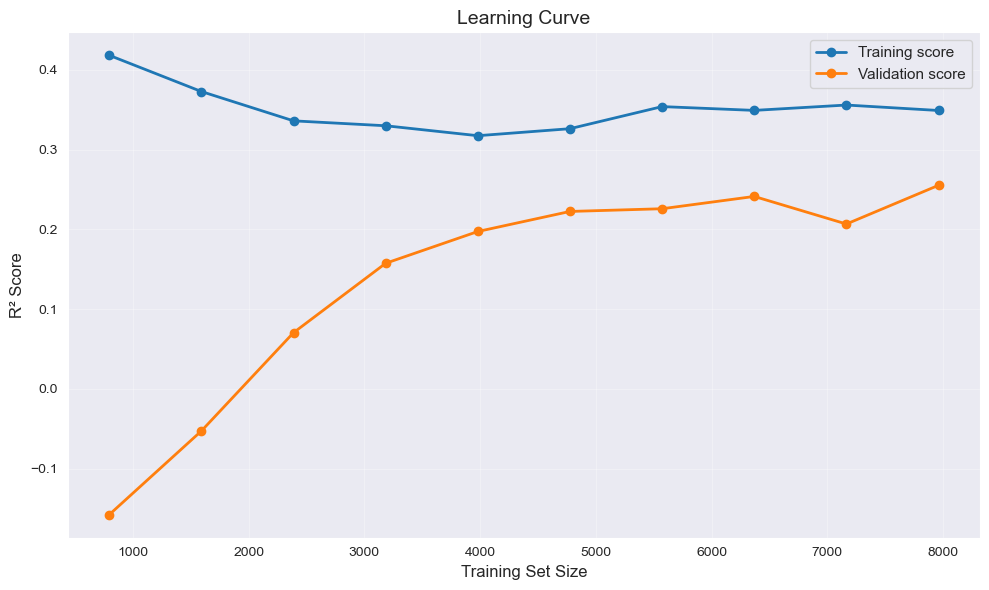

In [9]:
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores = []
val_scores = []

for size in train_sizes:
    n_samples = int(size * len(X_train_new))

    weights = 1 / (2022 - train_year_new + 1)

    # Fit on subset of training data
    best_model.fit(X_train_new[:n_samples], y_train_new[:n_samples], model__sample_weight=weights[:n_samples])

    # Score on training subset and validation set
    y_pred_train = best_model.predict(X_train_new[:n_samples])
    y_pred_val = best_model.predict(X_valid_new)

    train_r2 = r2_score(y_train_new[:n_samples], y_pred_train)
    val_r2 = r2_score(y_valid, y_pred_val)

    train_scores.append(train_r2)
    val_scores.append(val_r2)
    print(f"Size: {n_samples:4d} | Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

# Plot
plt.figure(figsize=(10, 6))
actual_sizes = [int(s * len(X_train_new)) for s in train_sizes]

plt.plot(train_sizes*len(X_train_new), train_scores, label='Training score', marker='o', linewidth=2)
plt.plot(train_sizes*len(X_train_new), val_scores, label='Validation score', marker='o', linewidth=2)

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curve', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(clean_labels)


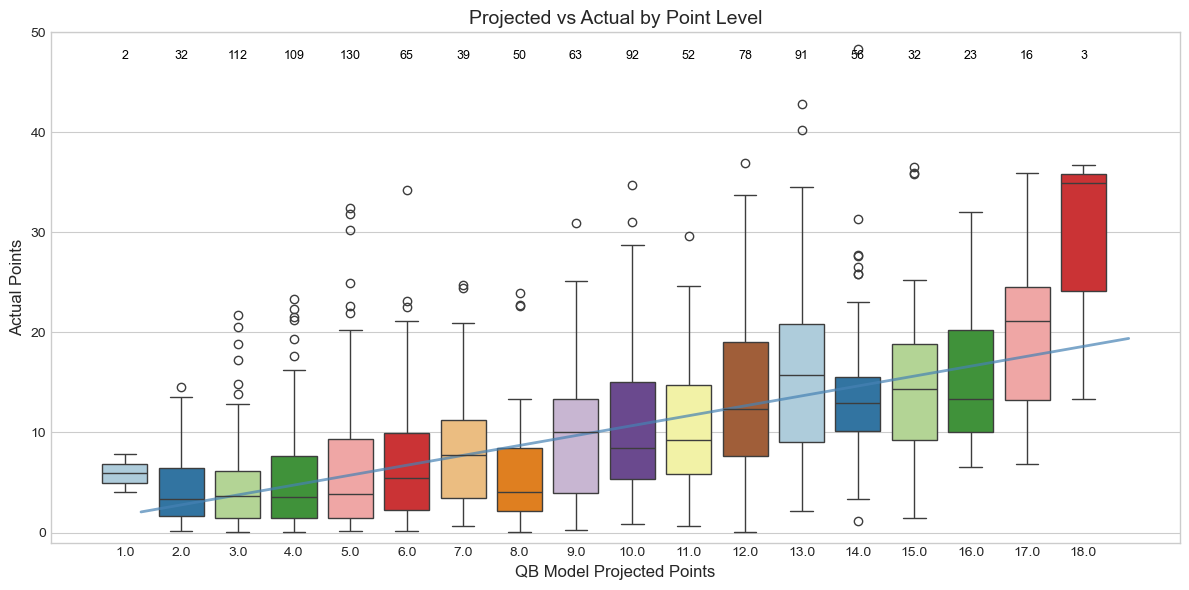

In [10]:
df = pd.DataFrame({
    "Projected": y_pred_valid,
    "Actual": y_valid
})


copy_plot(df)

C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thefr\AppData\Local\Temp\ipykernel_26044\2375925268.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(clean_labels)


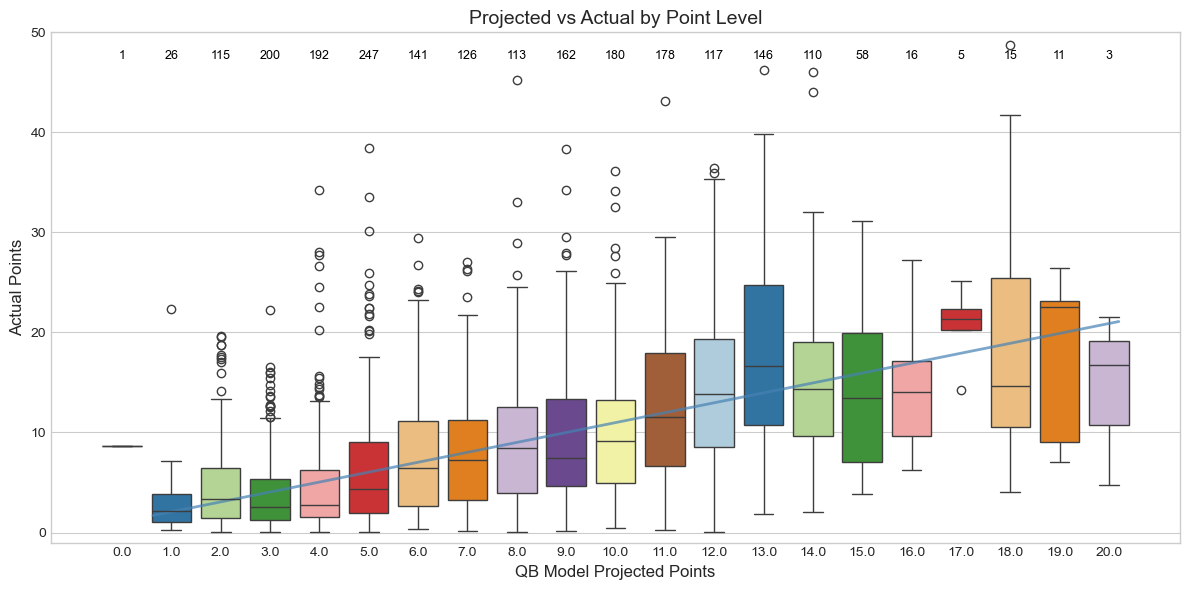

Model Evaluation Metrics:
Mean Squared Error (MSE): 47.8596
Root Mean Squared Error (RMSE): 6.9181
Mean Absolute Error (MAE): 5.0907
R² Score: 0.2432


In [11]:
df = pd.DataFrame({
    "Projected": best_model.predict(X_test_new),
    "Actual": y_test
})

copy_plot(df)

evaluate(y_test, best_model.predict(X_test_new))